# [ChatPromptTemplate](https://python.langchain.com/api_reference/core/prompts/langchain_core.prompts.chat.ChatPromptTemplate.html#chatprompttemplate)
> ChatPromptTemplate → "역할 기반 대화 구조"

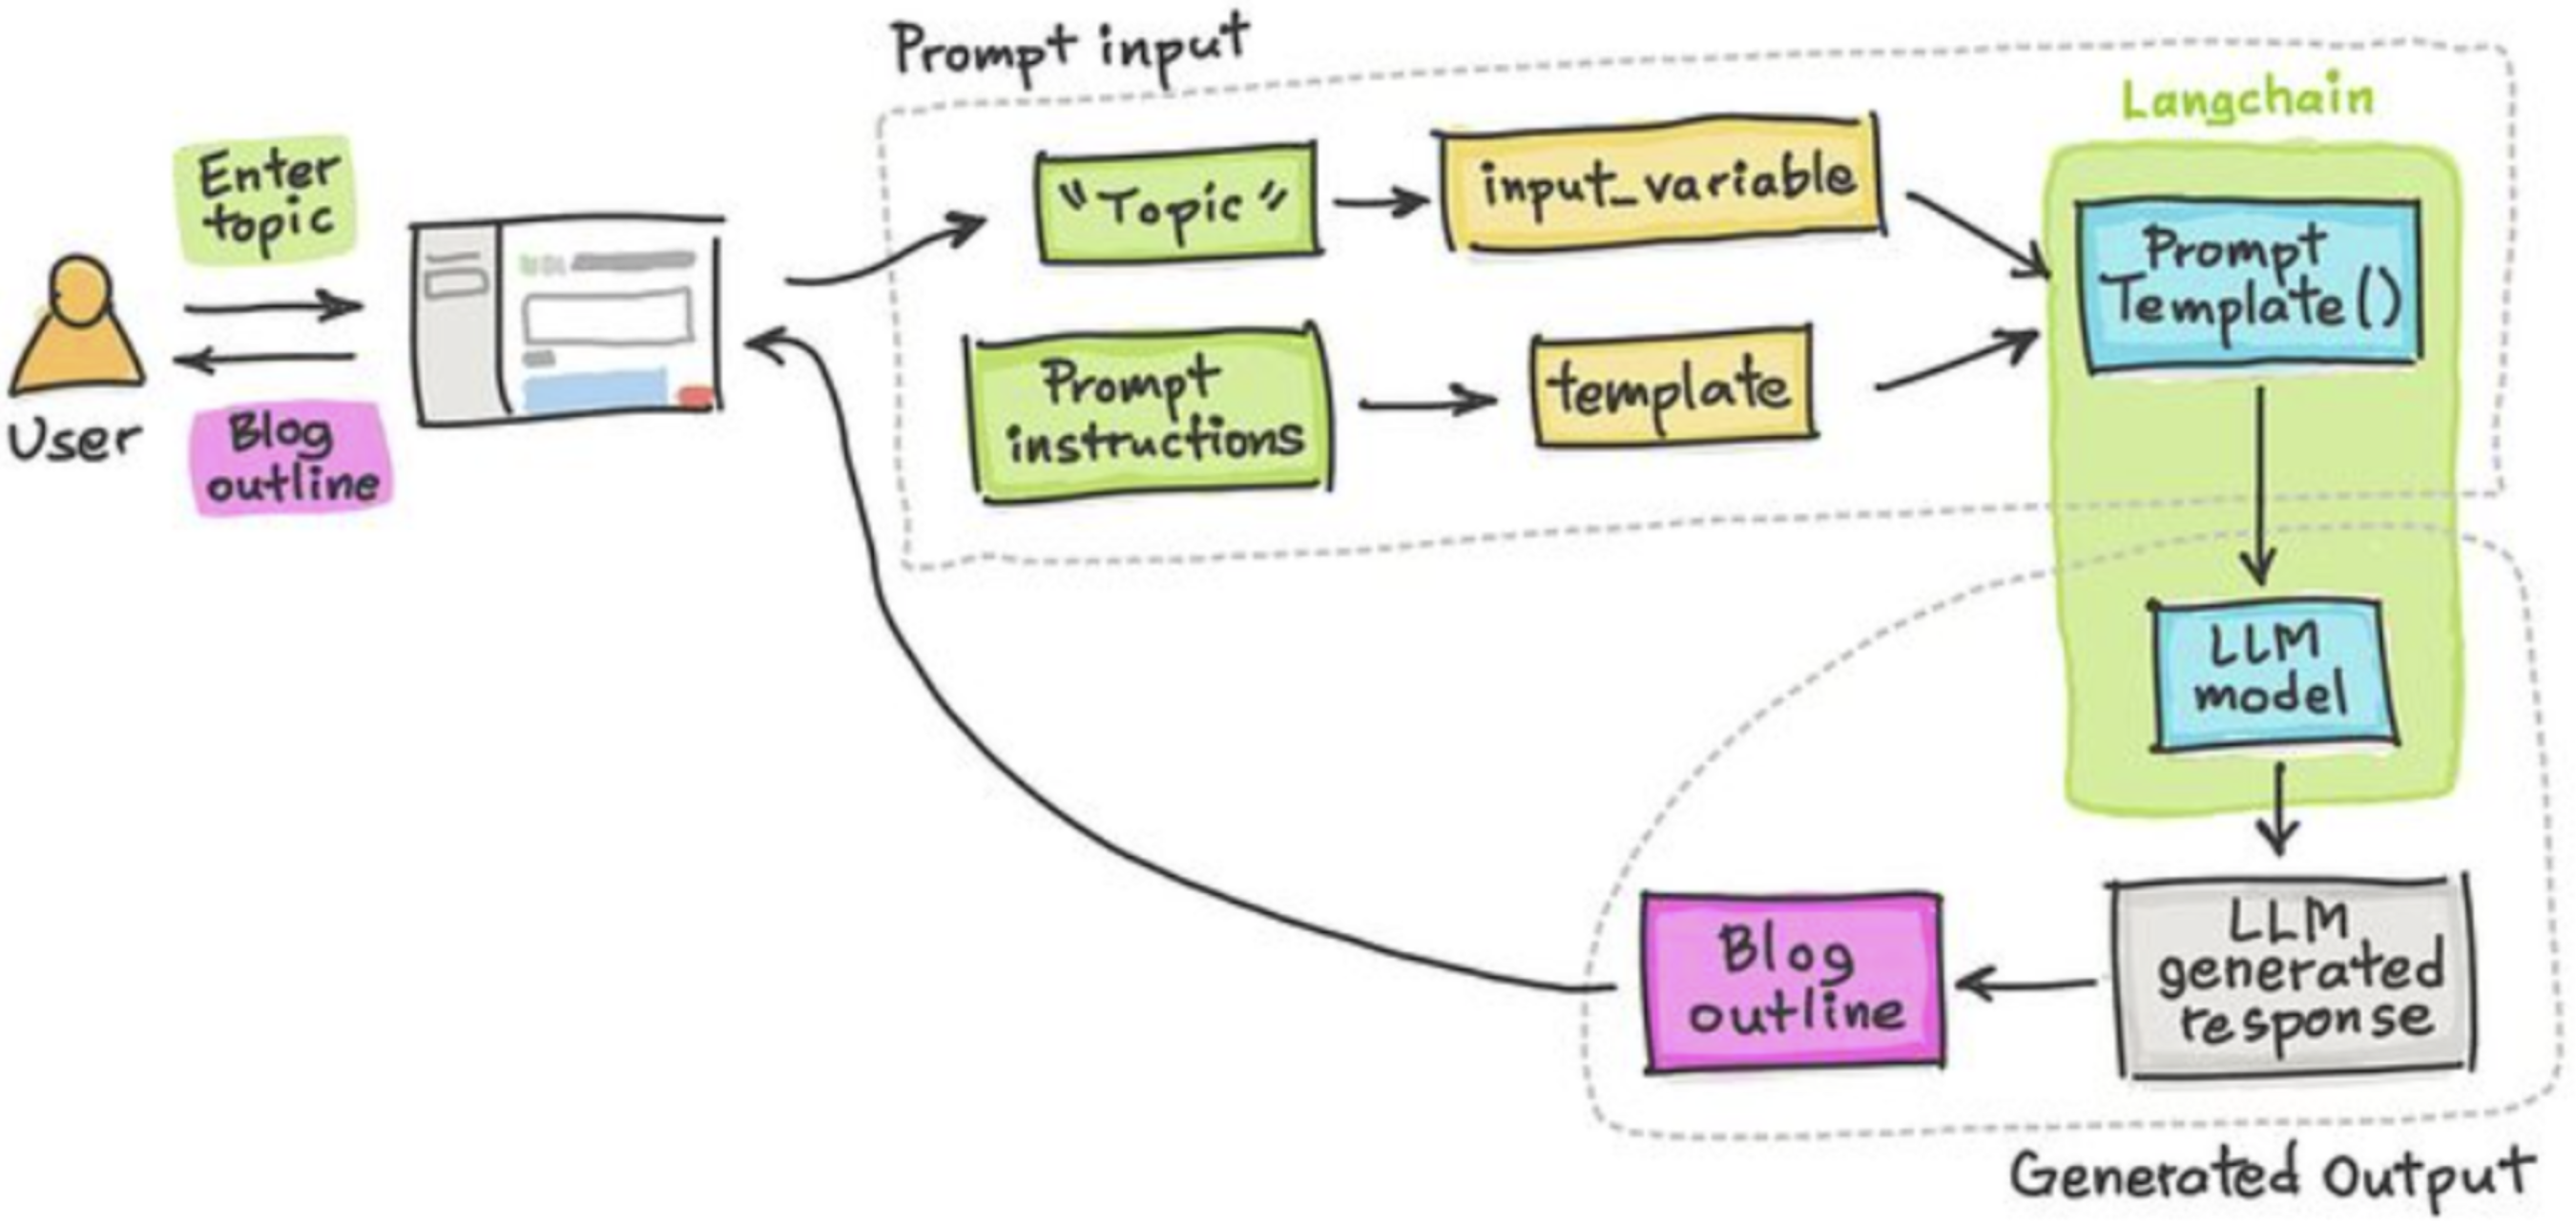

## 사용 상황:
- Chat 모델(OpenAI GPT, Claude 등)을 사용할 때
- system/human 메시지를 구분해 명확한 역할을 부여할 때

## 개념
- Chat 모델용 템플릿 (gpt-3.5-turbo, gpt-4, Claude, Gemini 등)
- 여러 역할(Role: system, human, ai) 메시지를 조합해서 프롬프트 구성
- PromptTemplate보다 구조화된 대화 형식

## Template 비교 

| 구분                        | 사용 목적          | 구조                   | 예시 기반 | 주로 사용하는 모델 | 대표 용도        |
| ------------------------- | -------------- | -------------------- | ----- | ---------- | ------------ |
| **PromptTemplate**        | 단일 텍스트 프롬프트    | 문자열                  | ❌     | 텍스트 LLM    | 단순 질의        |
| **ChatPromptTemplate**    | 대화형 프롬프트       | 메시지 목록(system/human) | ❌     | Chat LLM   | 챗봇, 대화형 질의   |
| **FewShotPromptTemplate** | 예시 포함 학습형 프롬프트 | 문자열 + 예시 리스트         | ✅     | 모든 LLM     | 예시 학습, 패턴 생성 |


# 예제 

## ChatPromptTemplate

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage
from langchain_core.prompts import HumanMessagePromptTemplate

# 시스템과 휴먼 역할을 정의한 채팅 프롬프트 템플릿 생성
chat_prompt = ChatPromptTemplate(
    messages=[
        # system 역할
        SystemMessage(
            content=(
                "당신은 친근하고 도움이 되는 AI 어시스턴트입니다. 항상 한국어로 답변해주세요."
            )
        ),
        # human 역할
        HumanMessagePromptTemplate.from_template(
            template="""
                {user_input}
            """
        ),
    ]
)


In [2]:
chat_prompt.input_variables

['user_input']

## Model

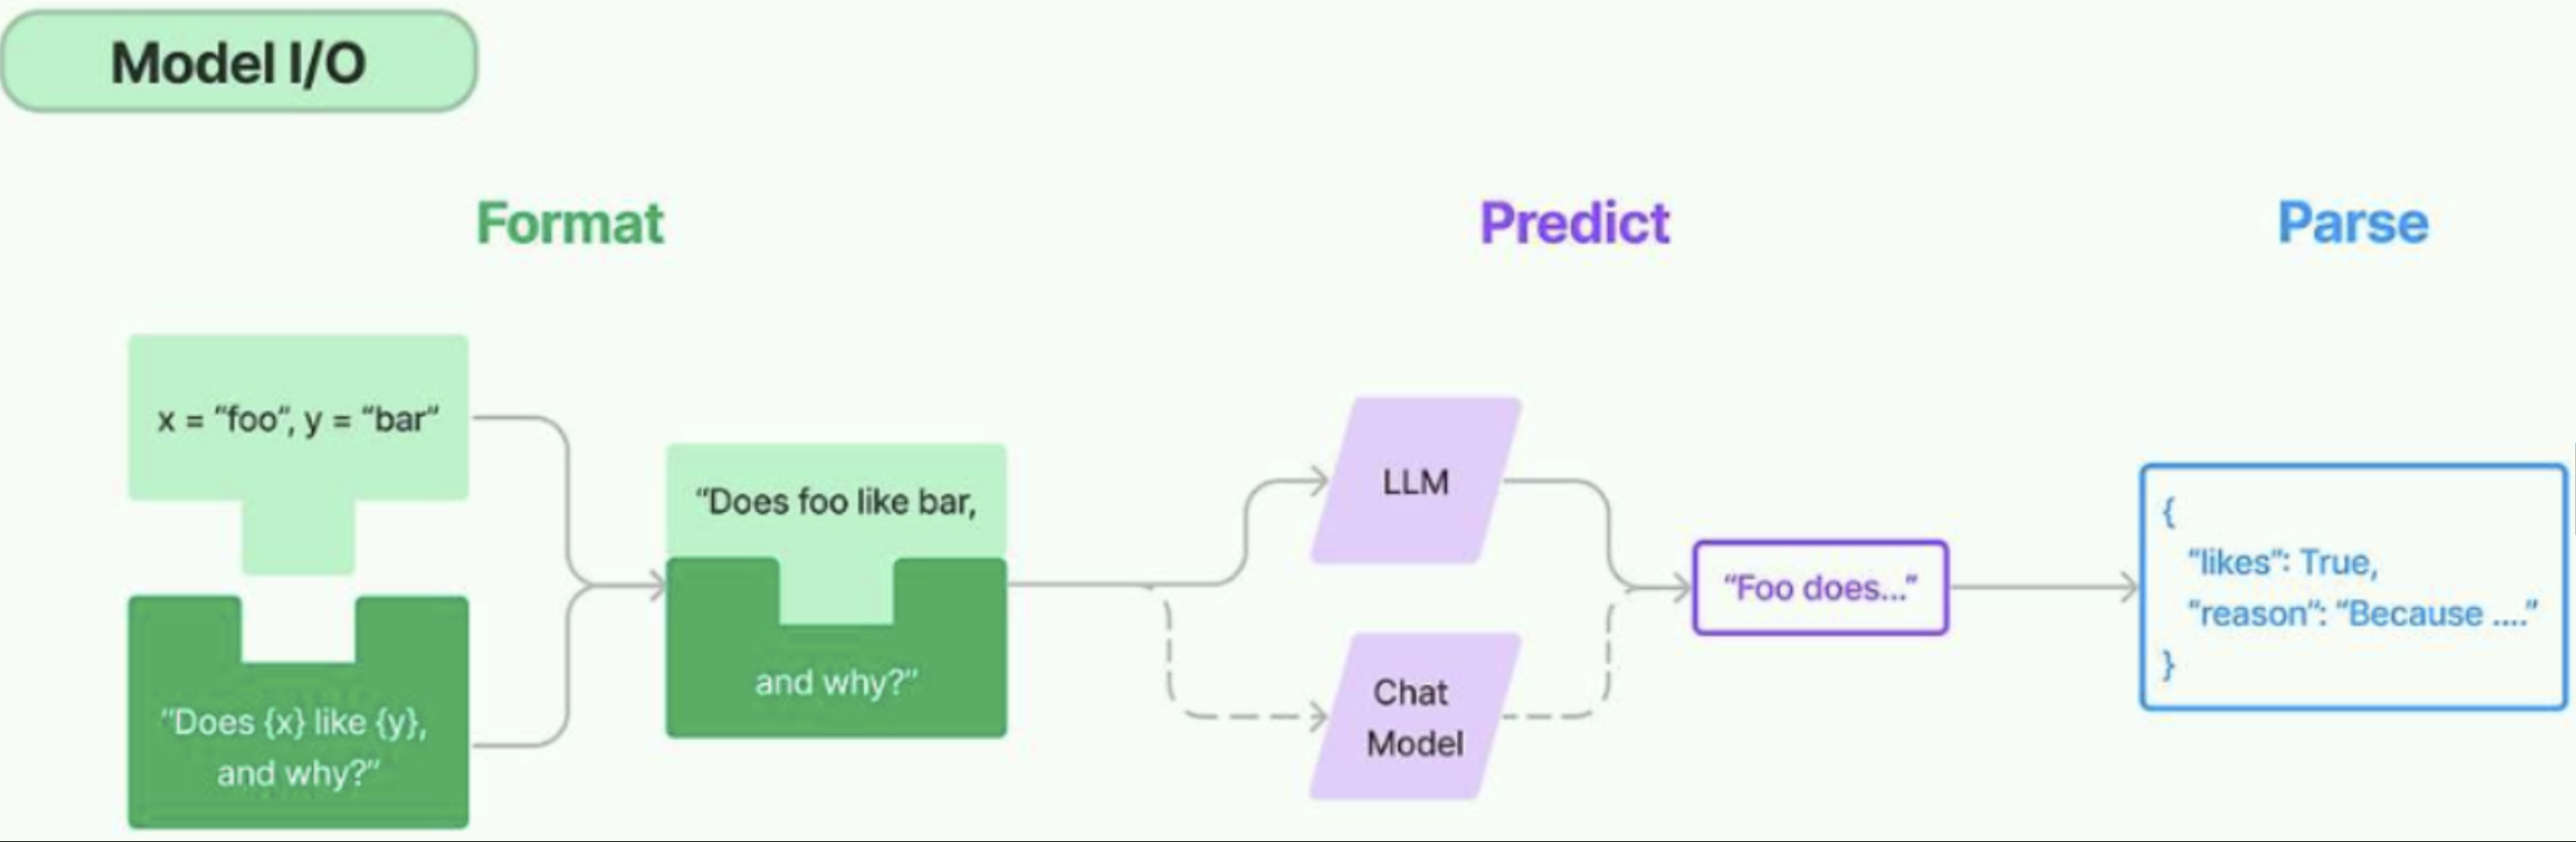

### [Groq API Key](https://console.groq.com/keys)

In [3]:
import os 

# 직접 적용 방법
# os.environ["GROQ_API_KEY"] = "sk-your_api_key_here"

In [4]:
from dotenv import load_dotenv

# dotenv 파일에서 환경변수 로드
load_dotenv()

True

In [5]:
# API 키 확인
api_key = os.getenv("GROQ_API_KEY")
if api_key:
    print("GROQ API 키가 설정되었습니다.")
else:
    print("GROQ API 키가 없습니다.")

GROQ API 키가 설정되었습니다.


### LLM

In [6]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-120b",         # 모델명
    temperature=0.1,                     
    model_kwargs={
        "top_p":0.9,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.7,         # 반복 억제
        "presence_penalty":0.6,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

## LangChain Expression Language (LCEL)
- LCEL은 LangChain에서 **체인(Chain)** 을 선언적으로 구성하기 위한 언어입니다.
- LangChain에서 **Chain**은 LLM 애플리케이션의 “작업 단계를 연결(Chain)”하는 핵심 개념입니다.
- 이 과정을 “체인(chain)” 형태로 구성하면 재사용성과 유지보수가 좋아집니다.
```
사용자 입력 → 프롬프트 구성 → LLM 호출 → 결과 반환
```

In [7]:
# chain 생성
chain = chat_prompt | model

In [8]:
# chain 호출 
response = chain.invoke({
    "user_input": "중력에 대해 설명해줘."
})


In [9]:
response

AIMessage(content='## 중력(重力)이란?\n\n**중력**은 물체가 서로 끌어당기는 힘을 말합니다. 우리 주변에서 가장 쉽게 느낄 수 있는 힘 중 하나이며, 지구가 우리를 땅에 붙잡아 두는 이유이기도 합니다. \n\n---\n\n## 1. 뉴턴의 만유인력 법칙\n\n### 기본 식\n\\[\nF = G \\frac{m_1 m_2}{r^2}\n\\]\n\n- **F** : 두 물체 사이에 작용하는 중력 (단위: 뉴턴, N)  \n- **G** : 만유인력 상수 \\(\\approx 6.674 \\times 10^{-11}\\, \\text{N·m}^2/\\text{kg}^2\\)  \n- **m₁, m₂** : 각각의 물체 질량 (kg)  \n- **r** : 두 물체 중심 사이 거리 (m)\n\n### 의미\n- 질량이 클수록, 거리 \\(r\\)이 작을수록 중력은 강해집니다.\n- 지구와 같은 큰 질량을 가진 천체는 주변 물체를 강하게 끌어당겨, 물체가 “떨어지는” 현상이 나타납니다.\n\n### 일상 예시\n- 사과가 나무에서 떨어지는 현상  \n- 우리가 땅에 서 있을 수 있는 이유  \n- 자동차가 도로 위에서 미끄러지지 않게 하는 마찰력은 중력에 의해 발생한 “무게”와 연결됩니다.\n\n---\n\n## 2. 아인슈타인의 일반 상대성 이론\n\n### 핵심 아이디어\n- **중력은 힘이 아니라 시공간(공간 + 시간)의 휘어짐**이라고 설명합니다.\n- 질량이 큰 물체가 주변 시공간을 휘게 만들고, 다른 물체는 그 휘어진 경로를 따라 움직입니다.\n\n### 비유\n- **고무 시트 위에 무거운 공을 놓는 것**을 생각해 보세요. 공이 시트를 눌러 움푹 파이게 되고, 그 주변에 작은 공을 놓으면 작은 공은 움푹 파인 부분을 따라 굴러갑니다. 이때 작은 공이 “끌리는” 것이 바로 중력입니다.\n\n### 실험적 증거\n- **빛의 굴절**: 별빛이 태양 근처를 지나갈 때 휘어지는 현상(1919년 일식 관측)  \n- **중력파**: 두 블

In [10]:
# 결과 확인 
print(response.content)

## 중력(重力)이란?

**중력**은 물체가 서로 끌어당기는 힘을 말합니다. 우리 주변에서 가장 쉽게 느낄 수 있는 힘 중 하나이며, 지구가 우리를 땅에 붙잡아 두는 이유이기도 합니다. 

---

## 1. 뉴턴의 만유인력 법칙

### 기본 식
\[
F = G \frac{m_1 m_2}{r^2}
\]

- **F** : 두 물체 사이에 작용하는 중력 (단위: 뉴턴, N)  
- **G** : 만유인력 상수 \(\approx 6.674 \times 10^{-11}\, \text{N·m}^2/\text{kg}^2\)  
- **m₁, m₂** : 각각의 물체 질량 (kg)  
- **r** : 두 물체 중심 사이 거리 (m)

### 의미
- 질량이 클수록, 거리 \(r\)이 작을수록 중력은 강해집니다.
- 지구와 같은 큰 질량을 가진 천체는 주변 물체를 강하게 끌어당겨, 물체가 “떨어지는” 현상이 나타납니다.

### 일상 예시
- 사과가 나무에서 떨어지는 현상  
- 우리가 땅에 서 있을 수 있는 이유  
- 자동차가 도로 위에서 미끄러지지 않게 하는 마찰력은 중력에 의해 발생한 “무게”와 연결됩니다.

---

## 2. 아인슈타인의 일반 상대성 이론

### 핵심 아이디어
- **중력은 힘이 아니라 시공간(공간 + 시간)의 휘어짐**이라고 설명합니다.
- 질량이 큰 물체가 주변 시공간을 휘게 만들고, 다른 물체는 그 휘어진 경로를 따라 움직입니다.

### 비유
- **고무 시트 위에 무거운 공을 놓는 것**을 생각해 보세요. 공이 시트를 눌러 움푹 파이게 되고, 그 주변에 작은 공을 놓으면 작은 공은 움푹 파인 부분을 따라 굴러갑니다. 이때 작은 공이 “끌리는” 것이 바로 중력입니다.

### 실험적 증거
- **빛의 굴절**: 별빛이 태양 근처를 지나갈 때 휘어지는 현상(1919년 일식 관측)  
- **중력파**: 두 블랙홀이나 중성자별이 합쳐질 때 발생하는 시공간의 파동(2015년 LIGO 관측)

---

## 3. 중력의 특징

| 특징 |